In [1]:
import os
import torch

import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from tqdm import tqdm

from matplotlib.image import imread
from scipy import sparse
from adj import main, combine_graph_dict
from train import train_model
from utils import mclust_R, fix_seed

In [2]:
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score
from sklearn.metrics import v_measure_score as v_score
from utils import compute_PAS, compute_CHAOS
from sklearn.decomposition import PCA

In [3]:
fix_seed(1)

In [4]:
#ABCD组6个    EFGH组3个

In [5]:
String = 'H'

patho_anno = pd.read_csv(f"../data/BreastCancer/her2st-master/data/ST-pat/lbl/{String}1_labeled_coordinates.tsv", index_col=0, sep='\t')


adata_st_list_raw = []

for i in range(1, 4):
    # st_count = pd.read_csv("./data/HER2-positive/count-matrices/E%d.tsv.gz" % i, index_col=0, sep='\t')
    # st_meta = pd.read_csv("./data/HER2-positive/spot-selections/E%d_selection.tsv.gz" % i, sep='\t')
    st_count = pd.read_csv(f"../data/BreastCancer/her2st-master/data/ST-cnts/{String}{i}.tsv.gz", index_col=0, sep='\t')
    st_meta = pd.read_csv(f"../data/BreastCancer/her2st-master/data/ST-spotfiles/{String}{i}_selection.tsv", sep='\t')
    st_meta.index = [str(st_meta['x'][i]) + 'x' + str(st_meta['y'][i]) for i in range(st_meta.shape[0])]
    st_meta = st_meta.loc[st_count.index]
    
    adata_st_i = ad.AnnData(X=st_count.values)
    adata_st_i.obs.index = st_count.index
    adata_st_i.obs = st_meta
    adata_st_i.var.index = st_count.columns
    
    img = imread(f'../data/BreastCancer/her2st-master/data/ST-imgs/{String}/{String}{i}.jpg')
    library_id = 'st'
    adata_st_i.uns["spatial"] = dict()
    adata_st_i.uns["spatial"][library_id] = dict()
    adata_st_i.uns["spatial"][library_id]['images'] = dict()
    adata_st_i.uns["spatial"][library_id]['images']['hires'] = img
    adata_st_i.uns["spatial"][library_id]['images']['lowres'] = img
    adata_st_i.uns["spatial"][library_id]['scalefactors'] = {'spot_diameter_fullres': 100,
                                                             'tissue_hires_scalef': 1.0,
                                                             'fiducial_diameter_fullres': 100,
                                                             'tissue_lowres_scalef': 1.0}
    
    adata_st_i.obsm['spatial'] = np.concatenate((np.array(st_meta["pixel_x"]).reshape(-1,1),
                                                 np.array(st_meta["pixel_y"]).reshape(-1,1)), axis=1)

    adata_st_i.obsm['loc_use'] = np.concatenate((np.array(st_meta["x"]).reshape(-1,1),
                                                 np.array(st_meta["y"]).reshape(-1,1)), axis=1)
    adata_st_i.obs['array_row'] = adata_st_i.obs["x"].values
    adata_st_i.obs['array_col'] = adata_st_i.obs["y"].values
    adata_st_i.obs['st_sample'] = String + str(i)

    if i == 1:
        adata_st_i.obs['annotation'] = None
        for idx in adata_st_i.obs.index:
            adata_st_i.obs['annotation'].loc[idx] = patho_anno[(patho_anno["x"] == adata_st_i[idx].obs["new_x"].values[0]) &
                                                               (patho_anno["y"] == adata_st_i[idx].obs["new_y"].values[0])]['label'].values[0]
    else:
        adata_st_i.obs['annotation'] = "Unknown"
    
    print(f'Slice {String}{i} spots:' + str(len(adata_st_i.obs)))

    adata_st_list_raw.append(adata_st_i)

Slice H1 spots:613
Slice H2 spots:603
Slice H3 spots:510


In [6]:
adata_st_list_raw

[AnnData object with n_obs × n_vars = 613 × 15029
     obs: 'x', 'y', 'new_x', 'new_y', 'pixel_x', 'pixel_y', 'selected', 'array_row', 'array_col', 'st_sample', 'annotation'
     uns: 'spatial'
     obsm: 'spatial', 'loc_use',
 AnnData object with n_obs × n_vars = 603 × 14907
     obs: 'x', 'y', 'new_x', 'new_y', 'pixel_x', 'pixel_y', 'selected', 'array_row', 'array_col', 'st_sample', 'annotation'
     uns: 'spatial'
     obsm: 'spatial', 'loc_use',
 AnnData object with n_obs × n_vars = 510 × 14873
     obs: 'x', 'y', 'new_x', 'new_y', 'pixel_x', 'pixel_y', 'selected', 'array_row', 'array_col', 'st_sample', 'annotation'
     uns: 'spatial'
     obsm: 'spatial', 'loc_use']

In [7]:
slice_use = []
for i in range(1,4):
    slice_id = String + str(i)
    slice_use.append(slice_id)
slice_use

['H1', 'H2', 'H3']

In [8]:
adata = None
for i, proj_name in enumerate(slice_use):

    adata_tmp = adata_st_list_raw[i]
    adata_tmp.obs['batch_name'] = adata_tmp.obs['st_sample']
    graph_dict_tmp = main(adata_tmp, adj_cons_by='coordinate', distType='KNN', k_cutoff=5, rad_cutoff=250)
    
    ##### Load layer_guess label, if have
    # df_label = pd.read_csv(data_root / proj_name / 'manual_annotations.txt', sep='\t', header=None, index_col=0)
    # df_label.columns = ['layer_guess']
    # adata_tmp.obs['layer_guess'] = df_label['layer_guess']
    #adata_tmp= adata_tmp[~pd.isnull(adata_tmp.obs['layer_guess'])]
    
    if  adata is None:
        adata = adata_tmp
        graph_dict = graph_dict_tmp
        name = proj_name
        adata.obs['proj_name'] = proj_name
    else:
        var_names = adata.var_names.intersection(adata_tmp.var_names)
        adata = adata[:, var_names]
        adata_tmp = adata_tmp[:, var_names]
        adata_tmp.obs['proj_name'] = proj_name
    
        adata = adata.concatenate(adata_tmp)
        graph_dict = combine_graph_dict(graph_dict, graph_dict_tmp)
        name = name + '_' + proj_name

------Calculating spatial graph...
The graph contains 3065 edges, 613 cells.
5.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 3015 edges, 603 cells.
5.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 2550 edges, 510 cells.
5.0000 neighbors per cell on average.


In [9]:
adata

AnnData object with n_obs × n_vars = 1726 × 13729
    obs: 'x', 'y', 'new_x', 'new_y', 'pixel_x', 'pixel_y', 'selected', 'array_row', 'array_col', 'st_sample', 'annotation', 'batch_name', 'proj_name', 'batch'
    obsm: 'spatial', 'loc_use'

In [10]:
adata.layers['count'] = adata.X
sc.pp.filter_genes(adata, min_cells=50)
sc.pp.filter_genes(adata, min_counts=10)
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=1000)
adata = adata[:, adata.var['highly_variable'] == True]
sc.pp.scale(adata)

from sklearn.decomposition import PCA  # sklearn PCA is used because PCA in scanpy is not stable. 
adata_X = PCA(n_components=200, random_state=42).fit_transform(adata.X)
adata.obsm['X_pca'] = adata_X

In [11]:
SpaBatch_net = train_model(adata, graph_dict, pre_epochs=400 ,epochs=500, mask_rate=0.1)
using_dec = True
if using_dec:
    SpaBatch_net.train_with_dec(num_aggre=1)
else:
    SpaBatch_net.train_without_dec()

Epoch 399 total loss=37.133: 100%|██████████ [ time left: 00:00 ]    
Epoch 499 total loss=16.405 recon loss=15.461 kl loss=0.050 tri loss=0.449 : |           [ time left: 00:00 ]    


In [12]:
SpaBatch_feat, _ = SpaBatch_net.process()
adata.obsm['SpaBatch'] = SpaBatch_feat

In [13]:
# adata1 = adata[adata.obs['batch_name'] == 'A1']
# adata1.obs['annotation'].unique()

In [14]:
mclust_R(adata, num_cluster=6, used_obsm='SpaBatch')

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |===================================                                   |  50%

Exception ignored from cffi callback <function _callback at 0x000001BFAD171580>:
Traceback (most recent call last):
  File "D:\anaconda\envs\njy\Lib\site-packages\rpy2\rinterface_lib\callbacks.py", line 326, in _callback
    @ffi_proxy.callback(ffi_proxy._callback_def,
    
  File "D:\anaconda\envs\njy\Lib\site-packages\rpy2\rinterface.py", line 92, in _sigint_handler
    raise KeyboardInterrupt()
KeyboardInterrupt: 


  |======================================================================| 100%


AnnData object with n_obs × n_vars = 1726 × 1000
    obs: 'x', 'y', 'new_x', 'new_y', 'pixel_x', 'pixel_y', 'selected', 'array_row', 'array_col', 'st_sample', 'annotation', 'batch_name', 'proj_name', 'batch', 'mclust'
    var: 'n_cells', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg'
    obsm: 'spatial', 'loc_use', 'X_pca', 'Tri_SEDR', 'SEDR'
    layers: 'count'

In [15]:
#adata = sc.read_h5ad('BC_G.h5ad')

In [16]:
sub_adata = adata[adata.obs['batch_name'] == String+str('1')]
ARI = ari_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total ARI:{ARI}")
NMI = nmi_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
AMI = ami_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total NMI:{NMI}")
print(f"total AMI:{AMI}")
HOM = hom_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
COM = com_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total HOM:{HOM}")
print(f"total COM:{COM}")
V =  2 * ((HOM * COM) / (HOM + COM))
print(f"total V:{V}")

total ARI:0.3213901682588181
total NMI:0.4443163292152883
total AMI:0.43568546130514585
total HOM:0.41153991395570033
total COM:0.4827653787227232
total V:0.4443163292152883


2.417193942424099


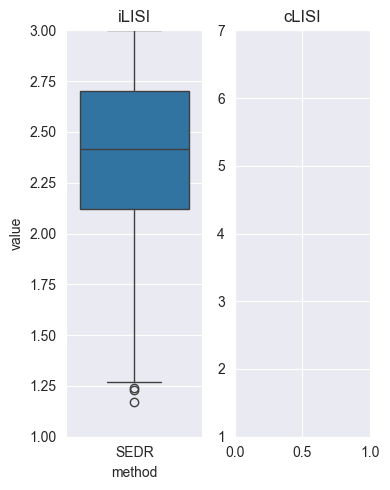

In [17]:
import harmonypy as hm

iLISI = hm.compute_lisi(adata.obsm['SpaBatch'], adata.obs[['batch_name']], label_colnames=['batch_name'])[:, 0]
#cLISI = hm.compute_lisi(adata.obsm['SpaBatch'], adata.obs[['annotation']], label_colnames=['annotation'])[:, 0]
df_iLISI = pd.DataFrame({
    'method': 'SpaBatch',
    'value': iLISI,
    'type': ['ILISI'] * len(iLISI)
})

# df_cLISI = pd.DataFrame({
#     'method': 'SpaBatch',
#     'value': cLISI,
#     'type': ['CLISI'] * len(cLISI)
# })

fig, axes = plt.subplots(1, 2, figsize=(4, 5))
sns.boxplot(data=df_iLISI, x='method', y='value', ax=axes[0])
#sns.boxplot(data=df_cLISI, x='method', y='value', ax=axes[1])
axes[0].set_ylim(1, 3)
axes[1].set_ylim(1, 7)
axes[0].set_title('iLISI')
axes[1].set_title('cLISI')

plt.tight_layout()
print(np.median(iLISI))
#print(np.median(cLISI))

In [18]:
plt.rcParams['axes.facecolor'] = 'white'  # 设置子图的背景颜色
plt.rcParams['figure.facecolor'] = 'white'  # 设置整张图的背景颜色

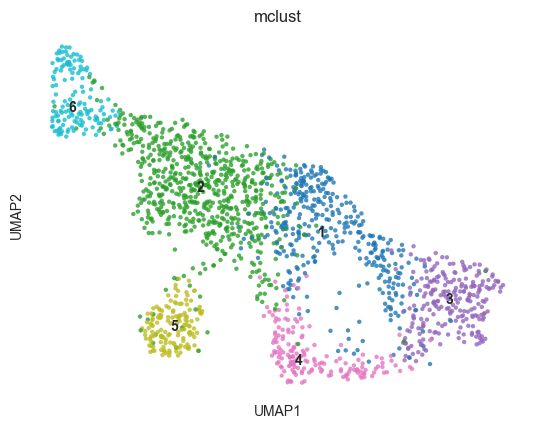

In [19]:
import scanpy as sc
import matplotlib.pyplot as plt

sc.pp.neighbors(adata, use_rep='SpaBatch', metric='cosine', n_neighbors=15)  # 可调整 n_neighbors
sc.tl.umap(adata)  # 调整 min_dist 参数优化聚类

sc.pl.umap(
    adata, 
    color=['mclust'], 
    size=40,  # 调整点大小
    alpha=0.8,  # 调整透明度
    palette='tab10',  # 自定义调色板
    legend_loc='on data'
)

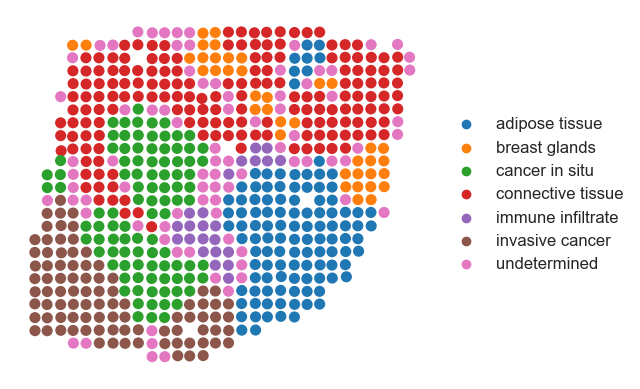

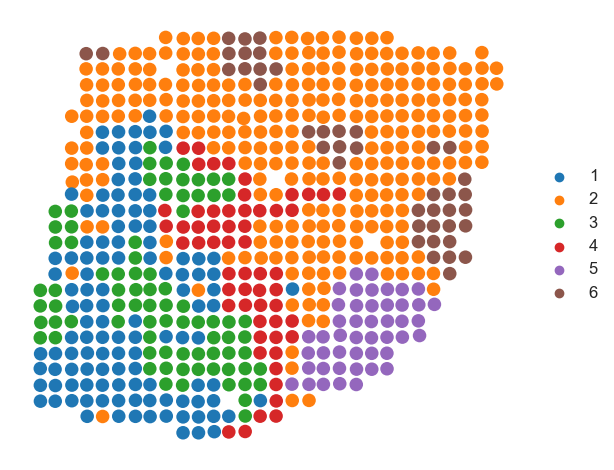

In [20]:
import matplotlib.pyplot as plt


adata_tmp_A1 = adata[adata.obs['batch_name'] == String+str(1)]
adata_tmp_A1.uns = adata_st_list_raw[1].uns

sc.pl.spatial(adata_tmp_A1, img_key='hires', color=['annotation'], title=[''],
              legend_loc='right margin', legend_fontsize=12, show=False, frameon=False, spot_size=250)

sc.pl.spatial(adata_tmp_A1, img_key='hires', color=['mclust'], title=[''],
              legend_loc='right margin', legend_fontsize=12, show=False, frameon=False, spot_size=250)

# sc.pl.scatter(adata_tmp_A1, 
#               x='x',  # 这里假设你的空间坐标 x 存储在 'spatial_x' 列中
#               y='y',  # 这里假设你的空间坐标 y 存储在 'spatial_y' 列中
#               color='annotation',  # 设置颜色为注释（annotation）
#               title='',  # 设置标题为空
#               legend_loc='right margin',  # 设置图例位置
#               legend_fontsize=12,  # 设置图例字体大小
#               show=False,  # 不自动显示图形
#               frameon=False)  # 不显示边框

# sc.pl.scatter(adata_tmp_A1, 
#               x='x',  # 这里假设你的空间坐标 x 存储在 'spatial_x' 列中
#               y='y',  # 这里假设你的空间坐标 y 存储在 'spatial_y' 列中
#               color='mclust',  # 设置颜色为注释（annotation）
#               title='',  # 设置标题为空
#               legend_loc='right margin',  # 设置图例位置
#               legend_fontsize=12,  # 设置图例字体大小
#               show=False,  # 不自动显示图形
#               frameon=False)  # 不显示边框

plt.tight_layout()

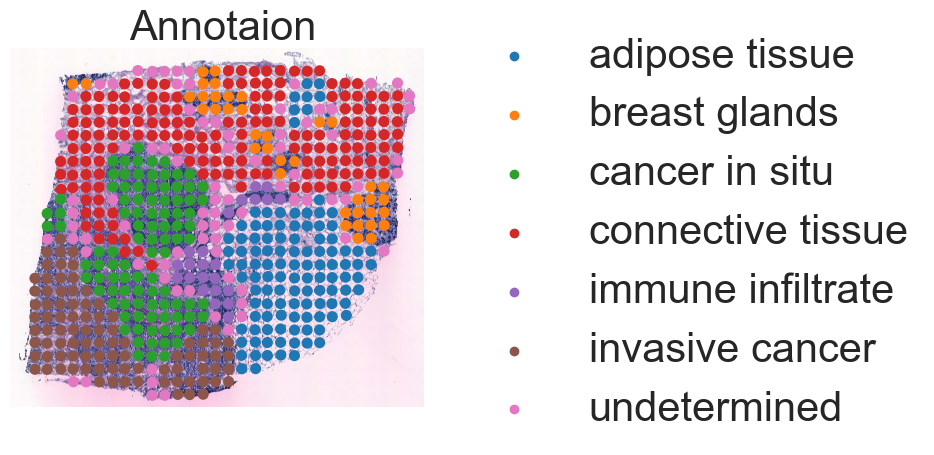

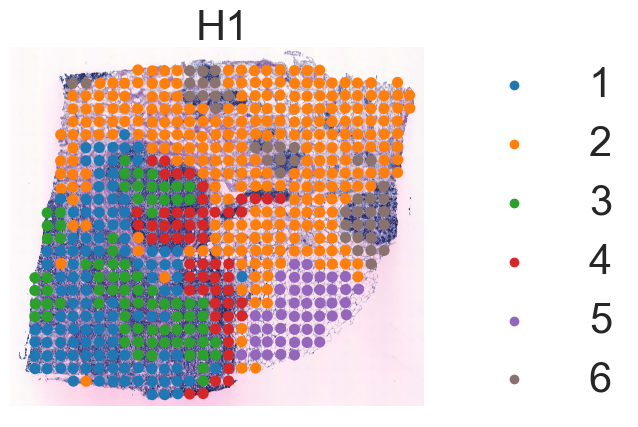

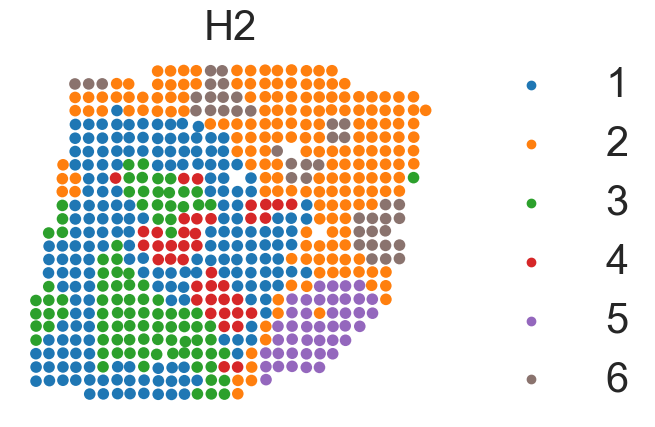

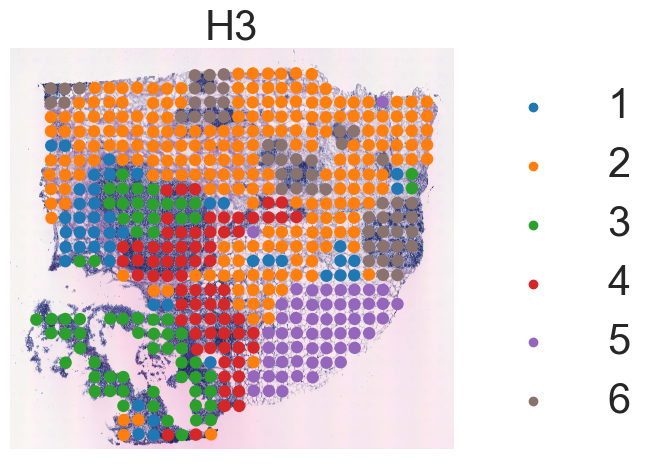

In [36]:
import matplotlib.pyplot as plt

cluster_colors = {
    1: '#1f77b4',  # Cluster 0 -> 蓝色
    2: '#ff7f0e',  # Cluster 1 -> 橙色
    3: '#2ca02c',  # Cluster 2 -> 绿色
    4: '#d62728',  # Cluster 3 -> 红色
    5: '#9467bd',  # Cluster 4 -> 紫色
    6: '#8a736e'   # Cluster 5 -> 
}


for i, slice_name in enumerate(slice_use):
    adata_tmp = adata[adata.obs['batch_name'] == String+str(i+1)]
    adata_tmp.uns = adata_st_list_raw[i].uns
    if i == 0:
        sc.pl.spatial(adata_tmp, img_key='hires', color=['annotation'], title=[''],
              legend_loc='right margin', legend_fontsize=30, show=False, frameon=False, spot_size=250)
        plt.title(f'Annotaion', fontsize=30)
        plt.savefig(f"D:\\njy\MutipelSliceSTD\MS\论文图表设计\Figure8_BC\FS12\\{String}\Annotaion_{i+1}.jpg", dpi=300, bbox_inches='tight')
    sc.pl.spatial(adata_tmp, img_key='hires', color=['mclust'], title=[''],
                  legend_loc='right margin', legend_fontsize=30, show=False, frameon=False, spot_size=250,
                  palette=cluster_colors)
    plt.title(f'{slice_name}', fontsize=30)
    plt.savefig(f"D:\\njy\MutipelSliceSTD\MS\论文图表设计\Figure8_BC\FS12\\{String}\Our_{i+1}.jpg", dpi=300, bbox_inches='tight')
plt.tight_layout()

In [22]:
#adata.write('BC_G_1.h5ad')

In [23]:
#差异分析

In [24]:
adata.obs["re_mclust"] =  adata.obs["mclust"].values.astype(str)

In [25]:
sc.tl.rank_genes_groups(adata, 're_mclust', groups=['1'], reference='3', key_added = "1vs3")
sc.tl.rank_genes_groups(adata, 're_mclust', groups=['3'], reference='1', key_added = "3vs1")

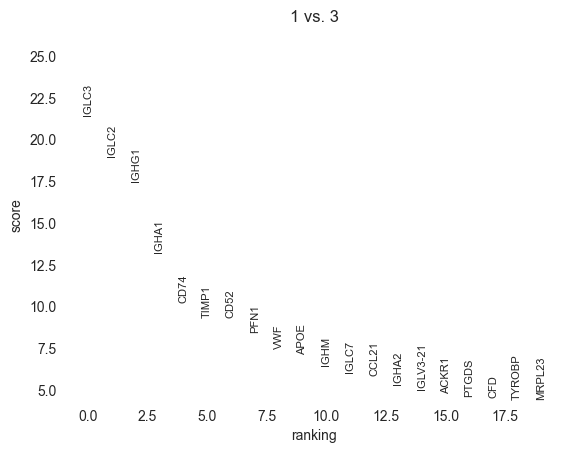

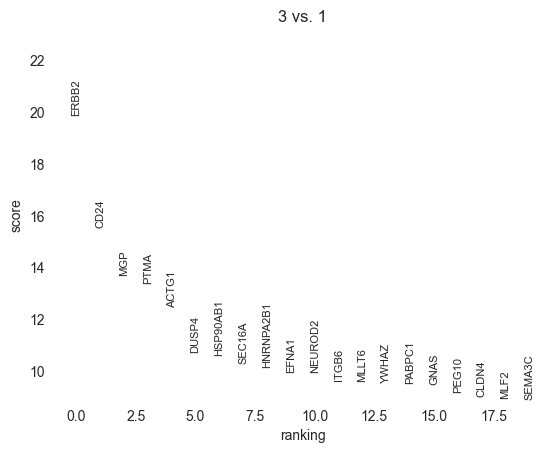

In [26]:
sc.pl.rank_genes_groups(adata, key="1vs3")
sc.pl.rank_genes_groups(adata, key="3vs1")

{'mainplot_ax': <Axes: >,
 'gene_group_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

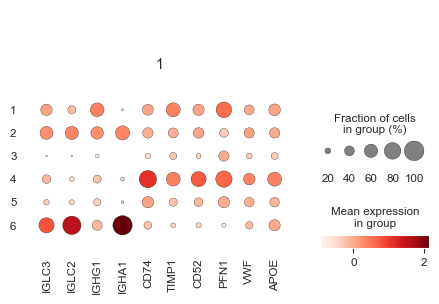

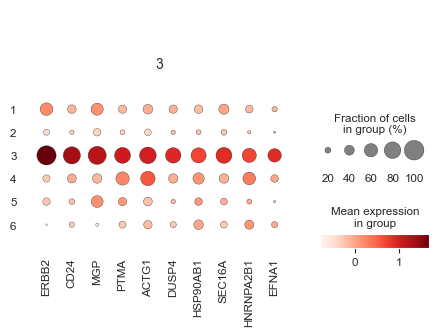

In [27]:
sc.pl.rank_genes_groups_dotplot(adata, groupby="re_mclust", dendrogram=False, show=False,key="1vs3")
sc.pl.rank_genes_groups_dotplot(adata, groupby="re_mclust", dendrogram=False, show=False,key="3vs1")

In [28]:
g_1vs3 = list(sc.get.rank_genes_groups_df(adata, group='1', key='1vs3', pval_cutoff=0.05, log2fc_min=0.25)['names'])
g_1vs3_differential_gene = g_1vs3[:10]
g_1vs3_differential_gene

['BEST1', 'HEBP2', 'CXCL14', 'SOD2', 'TPT1']

In [29]:
g_3vs1 = list(sc.get.rank_genes_groups_df(adata, group='3', key='3vs1', pval_cutoff=0.05, log2fc_min=0.25)['names'])
g_3vs1_differential_gene = g_3vs1[:10]
g_3vs1_differential_gene

['ERBB2',
 'MGP',
 'SEC16A',
 'MLLT6',
 'PTPRF',
 'XBP1',
 'YWHAQ',
 'ATP6V1C2',
 'WBP11',
 'HNRNPAB']

<Axes: title={'center': '1vs3'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

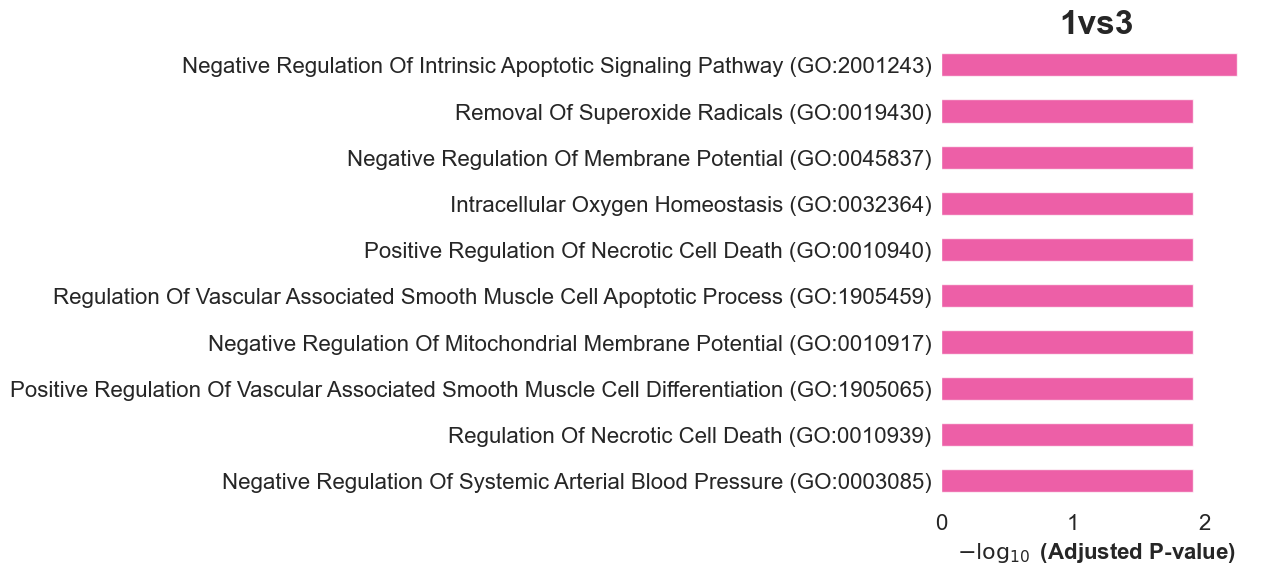

In [30]:
import gseapy

enr_res_1vs3 = gseapy.enrichr(gene_list=g_1vs3,
                         organism='Human',
                         gene_sets='GO_Biological_Process_2023',
                         cutoff = 0.5,
                         )
enr_res_1vs3.results.head()

gseapy.barplot(enr_res_1vs3.res2d,title='1vs3',color='#e7298a')

<Axes: title={'center': '3vs1'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

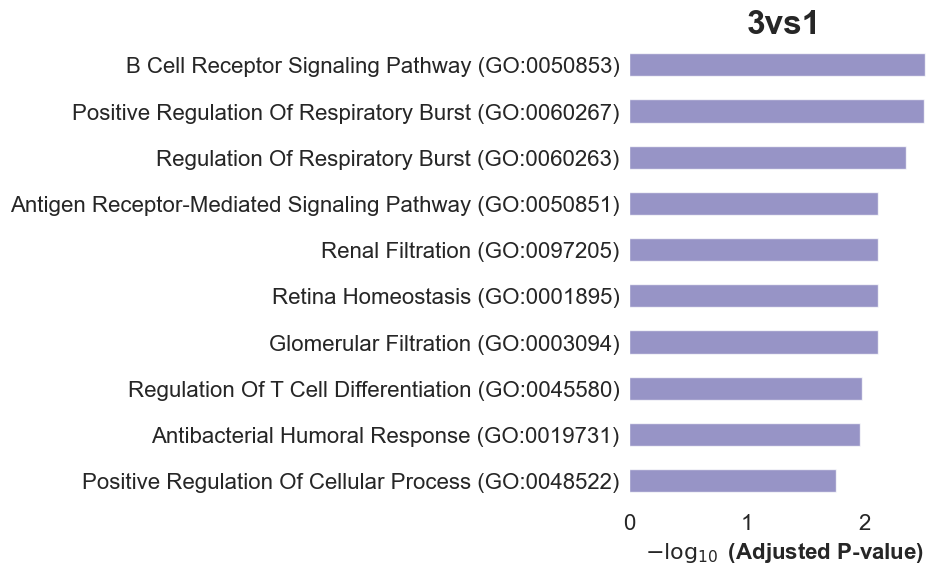

In [31]:
import gseapy

enr_res_3vs1 = gseapy.enrichr(gene_list=g_3vs1,
                         organism='Human',
                         gene_sets='GO_Biological_Process_2023',
                         cutoff = 0.5,
                         )
enr_res_3vs1.results.head()

gseapy.barplot(enr_res_3vs1.res2d,title='3vs1',color ='#7570b3')

In [32]:
dg = g_1vs3_differential_gene + g_3vs1_differential_gene
dg

['BEST1',
 'HEBP2',
 'CXCL14',
 'SOD2',
 'TPT1',
 'ERBB2',
 'MGP',
 'SEC16A',
 'MLLT6',
 'PTPRF',
 'XBP1',
 'YWHAQ',
 'ATP6V1C2',
 'WBP11',
 'HNRNPAB']

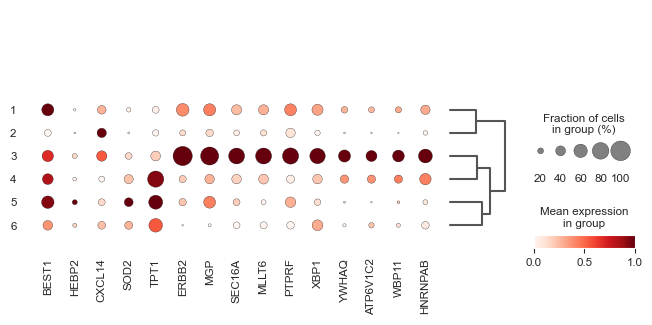

In [33]:
sc.pl.dotplot(adata, dg, groupby='re_mclust', dendrogram=True, swap_axes=False,standard_scale='var')

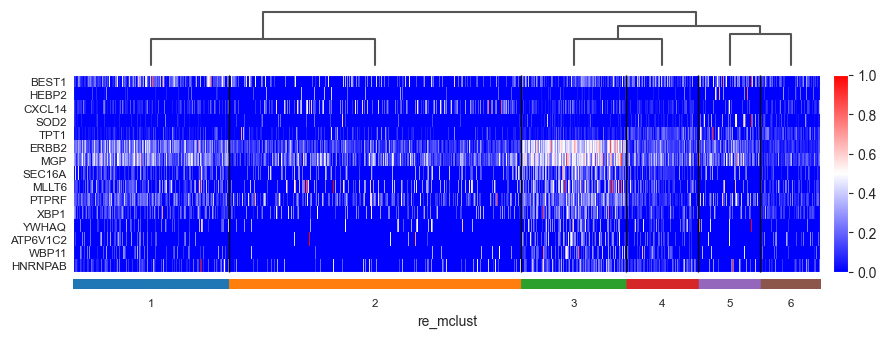

In [34]:
sc.pl.heatmap(adata, dg, groupby='re_mclust', show=True, cmap='bwr',swap_axes=True, dendrogram=True, standard_scale='var',save=False)

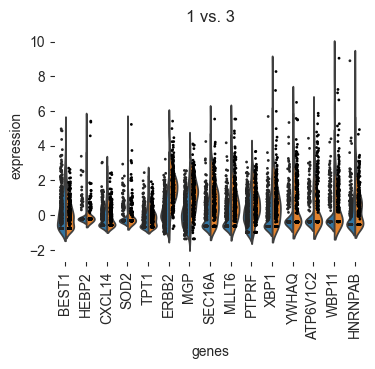

In [35]:
# 创建图形和坐标轴
fig, ax = plt.subplots(figsize=(4, 3))
# 设置坐标轴的位置
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
# 在坐标轴上绘制图形
sc.pl.rank_genes_groups_violin(adata, gene_names=dg, jitter=True, key='1vs3', size=2, ax=ax,save=False)